# Data Collection

## Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import spotipy
import pyarrow as pa
from spotipy.oauth2 import SpotifyOAuth
from dotenv import load_dotenv

load_dotenv()


True

Spotify login, tried to get top tracks (API failed)

In [10]:
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=os.getenv("SPOTIFY_CLIENT_ID"),
    client_secret=os.getenv("SPOTIFY_CLIENT_SECRET"),
    redirect_uri=os.getenv("SPOTIFY_REDIRECT_URI"),
    scope="user-top-read",
    show_dialog=True
))
print("Login erfolgreich")

Login erfolgreich


In [11]:
#Try to get the top tracks of the user, problems with API

results = sp.current_user_top_tracks(limit=5)

track_ids=[]
for i, item in enumerate(results["items"]):
    track_ids.append(item["id"])

print(track_ids[:5])
print(len(track_ids))
print(sp.current_user())

#audio_features = sp.audio_features(track_ids)
#sp.recommendations([track_ids])

['1NXbNEAcPvY5G1xvfN57aA', '4whkhyXTrTgHKZzkUvdwoq', '0iwF12YENrn1fvTE3COE3F', '2QD2SHsaiqMbgn8imTpyNr', '2q1ud1o0InOx8HZfDo26ym']
5
{'account_id': 'S9PjaLVQbV', 'display_name': 'Sebastian Rex', 'external_urls': {'spotify': 'https://open.spotify.com/user/1124349498'}, 'followers': {'href': None, 'total': 15}, 'href': 'https://api.spotify.com/v1/users/1124349498', 'id': '1124349498', 'images': [{'height': 300, 'url': 'https://scontent-tpe1-1.xx.fbcdn.net/v/t1.6435-1/40074867_2711646588861129_3824803758752137216_n.jpg?stp=dst-jpg_s320x320_tt6&_nc_cat=111&ccb=1-7&_nc_sid=08baa4&_nc_ohc=20FUZp8WxOoQ7kNvwHl2Jm8&_nc_oc=AdoozaumNnafU9-17u2yHjLAFyL7dCacomIjR6sy-HCTpXkdV90kqy_WW_sQ32--HHuQcZCu5NUkkzANk6ppoVr8&_nc_zt=24&_nc_ht=scontent-tpe1-1.xx&edm=AP4hL3IEAAAA&_nc_gid=-Brh2nmc8oldBAHMWj9a3g&_nc_tpa=Q5bMBQF8s_SogmKm3Ex1pSocGYJCuWJYTk4LJt5BiAild4Xxi5e8aT0LOu5JDpsOpGvLXpa4V0s8&oh=00_AQBH0v0S2E2J6uxX0Dnw1QjgiLtg8it9Pml-kltR6CxYhw&oe=6A76B1D5', 'width': 300}, {'height': 64, 'url': 'https://scontent

Loading streaming history data

In [12]:
#Import streaming history data

import sys
from pathlib import Path

# Projektordner zum Python-Suchpfad hinzufügen
project_root = Path.cwd().parent

sys.path.append(str(project_root))
from src.load_data import load_streaming_history
df = load_streaming_history(Path("../data/raw/my_spotify_data"))

..\data\raw\my_spotify_data\Streaming_History_Audio_2012.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2013.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2014.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2015.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2016.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2017.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2018.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2019.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2020.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2021.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2022.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2023.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2024.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2025.json
..\data\raw\my_spotify_data\Streaming_History_Audio_2026.json
..\data\raw\my_spotify_data\Streaming_History_Video_2020.json
..\data\

In [13]:
df.shape
df.info()
df.columns
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 132844 entries, 0 to 132843
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ts                                 132844 non-null  str    
 1   platform                           132844 non-null  str    
 2   ms_played                          132844 non-null  int64  
 3   conn_country                       132844 non-null  str    
 4   ip_addr                            132844 non-null  str    
 5   master_metadata_track_name         121274 non-null  object 
 6   master_metadata_album_artist_name  121274 non-null  object 
 7   master_metadata_album_album_name   121274 non-null  object 
 8   spotify_track_uri                  121274 non-null  object 
 9   episode_name                       11403 non-null   object 
 10  episode_show_name                  11403 non-null   object 
 11  spotify_episode_uri                11403 non-null 

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2012-04-02T09:35:44Z,Windows Vista (Unknown Ed) SP2 [x86 0],109854,DE,88.134.186.189,Illuminaudio,Chiodos,Illuminaudio,spotify:track:0z0K7qr8HQ9CHFLOf62jbZ,NaN,...,NaN,NaN,NaN,popup,trackdone,False,False,False,NaN,False
1,2012-04-02T09:39:24Z,Windows Vista (Unknown Ed) SP2 [x86 0],219516,DE,88.134.186.189,Caves,Chiodos,Illuminaudio,spotify:track:6hCn4yPyQxnaLXbqwfAOYG,NaN,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,NaN,False
2,2012-04-02T09:43:40Z,Windows Vista (Unknown Ed) SP2 [x86 0],255982,DE,88.134.186.189,Love Is a Cat From Hell,Chiodos,Illuminaudio,spotify:track:3P0AAP2eAssfNUI0cZPsA1,NaN,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,NaN,False
3,2012-04-02T09:47:29Z,Windows Vista (Unknown Ed) SP2 [x86 0],229102,DE,88.134.186.189,Modern Wolf Hair,Chiodos,Illuminaudio,spotify:track:26dIIcqM4lSVjG3ue8dJkp,NaN,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,NaN,False
4,2012-04-02T09:51:51Z,Windows Vista (Unknown Ed) SP2 [x86 0],261476,DE,88.134.186.189,Notes In Constellations,Chiodos,Illuminaudio,spotify:track:78WDQpXxWN1UE1d7oZlE0C,NaN,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,NaN,False


## Cleaning:
Dropped nAn's, Podcasts, zero seconds played

In [14]:
df_music = df.dropna(subset=["master_metadata_track_name"])
df_music["ts"]=pd.to_datetime(df_music["ts"], format="ISO8601")
df_music.drop(columns=["episode_name", "episode_show_name", "spotify_episode_uri", "audiobook_title", "audiobook_uri", "audiobook_chapter_uri", "audiobook_chapter_title"], inplace=True)
df_music = df_music[(df_music['ms_played'] > 0)]
df_music["minutes_played"] = df_music["ms_played"] / 1000 / 60


df_music.head()
df_music.info()

<class 'pandas.DataFrame'>
Index: 117971 entries, 0 to 132841
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype              
---  ------                             --------------   -----              
 0   ts                                 117971 non-null  datetime64[us, UTC]
 1   platform                           117971 non-null  str                
 2   ms_played                          117971 non-null  int64              
 3   conn_country                       117971 non-null  str                
 4   ip_addr                            117971 non-null  str                
 5   master_metadata_track_name         117971 non-null  object             
 6   master_metadata_album_artist_name  117971 non-null  object             
 7   master_metadata_album_album_name   117971 non-null  object             
 8   spotify_track_uri                  117971 non-null  object             
 9   reason_start                       117971 non-null  s

In [15]:
df_music["ms_played"].describe()

count    1.179710e+05
mean     1.873695e+05
std      1.474367e+05
min      1.000000e+00
25%      3.945550e+04
50%      2.034800e+05
75%      2.662530e+05
max      9.743581e+06
Name: ms_played, dtype: float64

In [16]:
df_music["minutes_played"].describe()

count    117971.000000
mean          3.122825
std           2.457278
min           0.000017
25%           0.657592
50%           3.391333
75%           4.437550
max         162.393017
Name: minutes_played, dtype: float64

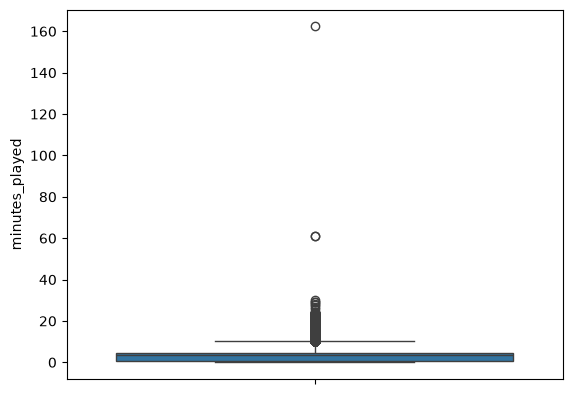

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y="minutes_played", data=df_music)
plt.show()

In [18]:
outliers = df_music[df_music["minutes_played"] > 25]

In [19]:
outliers


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,minutes_played
1882,2013-08-13 11:44:41+00:00,Windows 7 (6.1.7601; x86; SP1; S),1559600,DE,134.96.116.191,In the Presence of Enemies - Live at Rotterdam...,Dream Theater,Chaos in Motion 2007 - 2008,spotify:track:0i9aqK4RTTkxWJv760to5h,backbtn,trackdone,False,False,False,NaN,False,25.993333
2152,2013-09-21 11:16:30+00:00,Windows 8 (6.2.9200; x64),1821933,DE,95.89.243.194,The Great Escape,Seventh Wonder,The Great Escape,spotify:track:4UfVebCrJDvx2OwDMt9Vly,trackdone,trackdone,False,False,False,NaN,False,30.365550
6653,2014-07-03 22:21:38+00:00,"iOS 7.0.6 (iPhone5,2)",1758426,DE,95.89.245.83,Dazed And Confused - 2007 Remastered Version L...,Led Zeppelin,The Song Remains The Same,spotify:track:40FflFy3FGPax5bbGWOU5Z,fwdbtn,trackdone,False,False,False,NaN,False,29.307100
8006,2014-08-19 13:20:29+00:00,Windows 7 (6.1.7601; x86; SP1; S),3650687,DE,130.149.66.58,Thursday Afternoon - 2005 Digital Remaster,Brian Eno,Thursday Afternoon,spotify:track:4t3Yh6tKkxXrc458pNI7zZ,clickrow,trackdone,False,False,False,NaN,False,60.844783
8007,2014-08-19 13:20:29+00:00,Windows 7 (6.1.7601; x86; SP1; S),3650687,DE,130.149.66.58,Thursday Afternoon - 2005 Digital Remaster,Brian Eno,Thursday Afternoon,spotify:track:4t3Yh6tKkxXrc458pNI7zZ,clickrow,trackdone,False,False,False,NaN,False,60.844783
9448,2014-09-21 19:32:33+00:00,Windows 8 (6.2.9200; x64),1669622,DE,77.12.200.211,Kristina,Pickers,Modern,spotify:track:4u1GmDSuKMsEqxSTTsU2sT,clickrow,trackdone,False,False,False,NaN,False,27.827033
9613,2014-09-25 12:49:18+00:00,Windows 7 (6.1.7601; x86; SP1; S),1703841,DE,130.149.66.58,Thursday Afternoon - 2005 Digital Remaster,Brian Eno,Thursday Afternoon,spotify:track:4t3Yh6tKkxXrc458pNI7zZ,clickrow,endplay,False,True,False,NaN,False,28.397350
10275,2014-10-13 08:06:28+00:00,"iOS 7.0.6 (iPhone5,2)",9743581,DE,80.187.107.34,Journey Through The Dark,Blind Guardian,Somewhere Far Beyond,spotify:track:0lJVZoA5G1spAyfLKZQkNA,trackdone,trackdone,True,False,False,NaN,False,162.393017
26612,2018-02-27 21:51:02+00:00,"iOS 11.2.6 (iPhone9,3)",1758426,DE,95.91.214.132,Dazed And Confused - 2007 Remastered Version L...,Led Zeppelin,The Song Remains The Same,spotify:track:40FflFy3FGPax5bbGWOU5Z,trackdone,trackdone,False,False,False,NaN,False,29.307100
31735,2018-08-21 14:45:50+00:00,"iOS 11.4.1 (iPhone9,3)",1614000,DE,95.91.212.205,"Piano Sonata No. 32 In C Minor, Op. 111: 2. Ar...",Ludwig van Beethoven,"Beethoven: Piano Sonata No.32, Op.111; Bagatelles",spotify:track:0ybCSNfLium4wmXdMwIyya,trackdone,trackdone,False,False,False,NaN,False,26.900000


Dropped outliers

In [20]:
df_music = df_music[(df_music['ms_played'] != 1669622)]
df_music = df_music[(df_music['ms_played'] != 9743581)]
df_music = df_music[(df_music['master_metadata_album_artist_name'] != 'Reclam Hörbücher')]

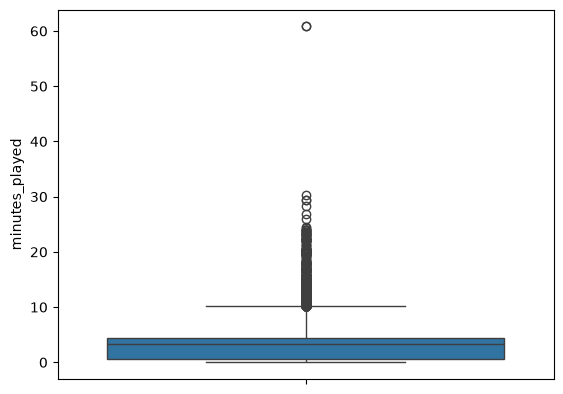

In [21]:
sns.boxplot(data=df_music, y="minutes_played")
plt.show()

## Saving clean music dataframe

In [22]:
df_music.info()

<class 'pandas.DataFrame'>
Index: 116571 entries, 0 to 132841
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype              
---  ------                             --------------   -----              
 0   ts                                 116571 non-null  datetime64[us, UTC]
 1   platform                           116571 non-null  str                
 2   ms_played                          116571 non-null  int64              
 3   conn_country                       116571 non-null  str                
 4   ip_addr                            116571 non-null  str                
 5   master_metadata_track_name         116571 non-null  object             
 6   master_metadata_album_artist_name  116571 non-null  object             
 7   master_metadata_album_album_name   116571 non-null  object             
 8   spotify_track_uri                  116571 non-null  object             
 9   reason_start                       116571 non-null  s

In [23]:
df_music.to_pickle("../data/processed/df_music_clean.pkl")